# REPORT plots (thesis figures)

Curated figures for the thesis report. Built incrementally from `REPORT_plots_aide.ipynb`.

- Period-count summary: MNIST from `results_many_seeds/mnist/` (multi-seed); CIFAR from cached FINAL analysis (single seed)
- Output: `local/save/plots/report/final/`
- Summary bars: six experimental groups (Cat1 controls + non-control | Cat2 controls + non-control), pooled over MNIST / Inception / ResNet
- Error bars: mean ± 1.96·SEM; set `REPORT_SUMMARY_SEM_AXIS` to `"models"`, `"optimizers"`, or `"all"`

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
from pathlib import Path
from typing import Iterable

import matplotlib as mpl
import pandas as pd
from IPython.display import display


def _find_project_root(start: Path | None = None) -> Path:
	p = (start or Path.cwd()).resolve()
	for cand in [p, *p.parents]:
		if (cand / "pyproject.toml").is_file():
			return cand
	return p


PROJECT_ROOT = _find_project_root()
if str(PROJECT_ROOT) not in sys.path:
	sys.path.insert(0, str(PROJECT_ROOT))

from analysis.final.final_analysis_config import (
	DEFAULT_SCORE_FACTORS,
	EXPERT_MODEL_DIR_BY_DATASET,
	save_dir_for_dataset,
)
from analysis.final.final_experiment_display import (
	ExperimentDisplayLabels,
	normalize_experiment_display_label,
	rename_experiments_for_labels,
	sort_experiment_display_names,
)
from analysis.final.final_compare_all_optimizers_helpers import (
	build_df_long,
	build_period_novelty_offset_df,
	load_neuro_experimental_bars,
)
from analysis.final.load_final_analysis import run_final_analysis
from analysis.final.report_plots.report_plots_helper import (
	DEFAULT_SEED,
	ReportSummarySemAxis,
	aggregate_report_summary_sem,
	aggregate_experiment_optimizer_pooled_bar_sem,
	build_report_layerwise_bss_data,
	build_report_layerwise_btsp_pct_data,
	build_report_period_count_runs_mixed,
	build_report_spider_means,
	cat1_non_control_experiment_labels,
	filter_all_results_seed,
	plot_report_activation_angle_by_model_figure,
	plot_report_activation_angle_by_optimizer_figure,
	plot_report_steep_long_period_count_by_optimizer_figure,
	plot_report_theta_threshold_by_optimizer_figure,
	plot_report_layerwise_bss_from_data,
	plot_report_layerwise_btsp_pct_from_data,
	plot_report_pooled_bss_by_optimizer_from_data,
	plot_report_non_control_experiment_bars,
	plot_report_spider_pooled_figure,
	plot_report_summary_group_figure,
	plot_report_t_start_comparison_figure,
	plot_report_t_start_non_control_neighbor_bar_figure,
	prepare_report_non_control_runs,
	print_two_way_anova_on_ranks,
)
from analysis.final.report_optimizer_performance_helper import (
	build_report_theta_long,
	build_report_ttc_long,
)

sns = __import__("seaborn")
sns.set_theme(context="paper", style="whitegrid", font_scale=1.0)
mpl.rcParams["figure.dpi"] = 120
mpl.rcParams["savefig.dpi"] = 200
mpl.rcParams["axes.titlesize"] = 10
mpl.rcParams["axes.labelsize"] = 10
mpl.rcParams["xtick.labelsize"] = 9
mpl.rcParams["ytick.labelsize"] = 9

PLOT_DIR = "local/save/plots/report/final/"
Path(PLOT_DIR).mkdir(parents=True, exist_ok=True)

SHOW_SIGNIFICANCE = True
SHOW_INSIGNIFICANCE = True

N_CHECKPOINT_SAMPLES = 20
SCORE_FACTORS = dict(DEFAULT_SCORE_FACTORS)
SCORE_FACTORS["n_partial_decay_score"] = 0.0
SCORE_FACTORS["n_active_decay_score"] = 0.0
RESCORE = False
MINMAX_NORMALIZE_ROBUSTNESS = True
REPARSE_DIGIT_A = False
STRICT = False
BTSP_START_STRATEGY = "acceleration"
USE_REAL_PROGRESSION = True

# "models": mean over optimizers, then experiments; bar/SEM over models
# "optimizers": mean over models, then experiments; bar/SEM over optimizers
# "all": one mean ± SEM over all runs in each group (flat, no nested pooling)
REPORT_SUMMARY_SEM_AXIS: ReportSummarySemAxis = "all"

_EXPER_LABEL_SHUFFLE_ALL = r"$\text{Shuffle}_{all}$"
_EXPER_LABEL_SHUFFLE_NOPRE = "Control global (✗PT)"
_EXPER_LABEL_SHUFFLE_INTERLEAVED = r"$\text{Shuffle}_{interleaved}$"
_EXPER_LABEL_SEQ_NOPRE = "Control sequential (✗PT)"
_EXPER_LABEL_SEQ_PRE = "Control sequential (✔PT)"
_EXPER_LABEL_SHUFFLE_SEQ = r"$\text{Shuffle}_{seq}$"
_EXPER_LABEL_NO_PRETRAIN = " Control (no pretrain)"

LABELS = ExperimentDisplayLabels(
	shuffle_all=_EXPER_LABEL_SHUFFLE_ALL,
	shuffle_interleaved=_EXPER_LABEL_SHUFFLE_INTERLEAVED,
	shuffle_nopre=_EXPER_LABEL_SHUFFLE_NOPRE,
	seq_nopre=_EXPER_LABEL_SEQ_NOPRE,
	seq_pre=_EXPER_LABEL_SEQ_PRE,
	shuffle_seq=_EXPER_LABEL_SHUFFLE_SEQ,
	no_pretrain=_EXPER_LABEL_NO_PRETRAIN,
)


def rename_experiments(exp_name: str) -> str:
	return normalize_experiment_display_label(
		rename_experiments_for_labels(exp_name, LABELS), LABELS
	)


def _sort_experiment_display_names(labels: Iterable[str]) -> list[str]:
	return sort_experiment_display_names(labels, LABELS)

In [3]:
# FINAL checkpoints: MNIST supplements many_seeds gaps; CIFAR is single-seed throughout.
all_results: dict = {}
errors_all: list[dict] = []

for DATASET in ("mnist", "cifar10"):
	SAVE_DIR = str(save_dir_for_dataset(PROJECT_ROOT, DATASET))
	Path(SAVE_DIR).mkdir(parents=True, exist_ok=True)
	ar, tree, errors, _ds_key, model_ids = run_final_analysis(
		input_dir=PROJECT_ROOT / "results",
		output_dir=Path(SAVE_DIR),
		project_root=PROJECT_ROOT,
		expert_model_dir=EXPERT_MODEL_DIR_BY_DATASET[DATASET],
		n_checkpoint_samples=N_CHECKPOINT_SAMPLES,
		score_factors=SCORE_FACTORS,
		rescore=RESCORE,
		minmax_normalize_robustness=MINMAX_NORMALIZE_ROBUSTNESS,
		reparse_digit_a=REPARSE_DIGIT_A,
		strict=STRICT,
		btsp_start_strategy=BTSP_START_STRATEGY,
		use_real_progression=USE_REAL_PROGRESSION,
		dataset=DATASET,
		verbose_errors=True,
	)
	all_results.update(ar)
	errors_all.extend(errors or [])
	print(f"DATASET={DATASET} model_ids={model_ids} experiments={len(tree)} runs={len(ar)}")

if errors_all:
	display(pd.DataFrame(errors_all))

df_period_runs = build_report_period_count_runs_mixed(PROJECT_ROOT, all_results)
n_mnist = (df_period_runs["model_id"] == "dnn_5x64").sum()
n_cifar = len(df_period_runs) - n_mnist
print(
	f"summary run rows: total={len(df_period_runs)}  "
	f"mnist={n_mnist}  cifar={n_cifar}"
)

Experiments:   0%|          | 0/10 [00:00<?, ?it/s]

Robustness already min-max normalized in cached runs; skipped min-max normalization
DATASET=mnist model_ids=['dnn_5x64'] experiments=10 runs=50


Experiments:   0%|          | 0/16 [00:00<?, ?it/s]

Robustness already min-max normalized in cached runs; skipped min-max normalization
DATASET=cifar10 model_ids=['inception_small_dnn_5x64', 'resnet32_dnn_5x64'] experiments=16 runs=100
summary run rows: total=420  mnist=320  cifar=100


## BTSP requires novelty

Six summary groups (pooled over all models and optimizers):

1. Control global (✗PT)
2. Control global (✔PT)
3. Non-control global — mean over remaining Cat1 experiments
4. *(Cat1 | Cat2 divider)*
5. Control sequential (✗PT)
6. Control sequential (✔PT)
7. Non-control sequential — mean over non-control Cat2 experiments

Each bar: mean ± 1.96·SEM. MNIST rows are multi-seed (`results_many_seeds`); CIFAR rows are single-seed FINAL checkpoints. Pooling controlled by `REPORT_SUMMARY_SEM_AXIS`: nested paths average seeds first (per experiment × optimizer × model), then pool non-control experiments; `"all"` is a flat mean ± SEM over every run row in the group.

*Note: from the Optimizer profiles section onward, all figures use **seed 3003 only** (MNIST multi-seed runs are excluded).*

**Non-control breakdown:** two grouped-bar figures — non-control global and non-control sequential — with one x-tick per experiment; within each tick, optimizers are grouped with **2 model bars** (MNIST, pooled CIFAR). MNIST: mean ± 1.96·SEM over seeds; CIFAR: mean ± 1.96·SEM over Inception and ResNet.

Saved /home/garvalov/thesis/plateau_optimizer/network_analyzer/analysis/notebooks/local/save/plots/report/final/final_btsp_requires_novelty.pdf


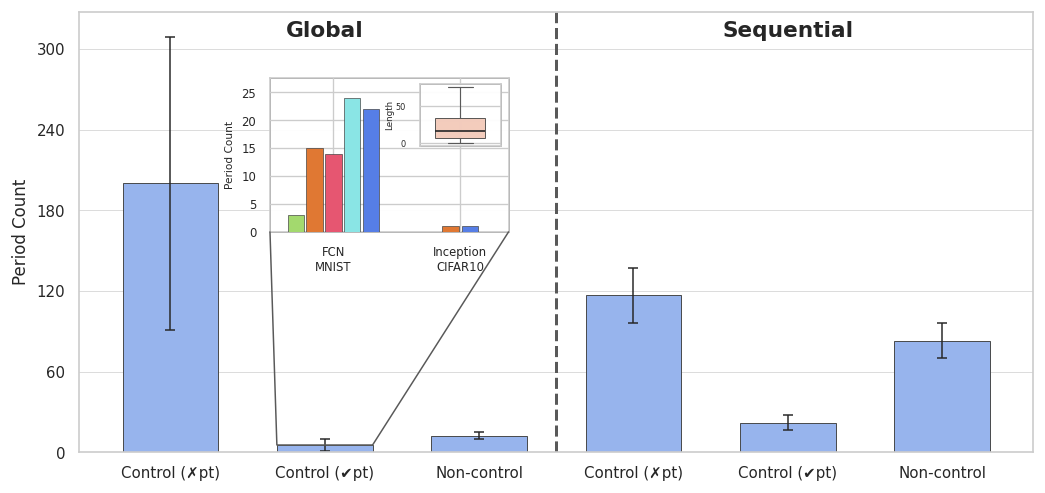

,report_group,mean,sem,ci_lo,ci_hi
0,cat1_control_global_nopre,200.066667,55.736441,90.823241,309.310092
1,cat1_control_global_pre,5.333333,2.252336,0.918755,9.747911
2,cat1_non_control,12.377778,1.152346,10.119180,14.636376
3,cat2_control_seq_nopre,116.666667,10.346424,96.387676,136.945657
4,cat2_control_seq_pre,22.066667,2.761276,16.654565,27.478768
5,cat2_non_control,82.948148,6.604330,70.003662,95.892635


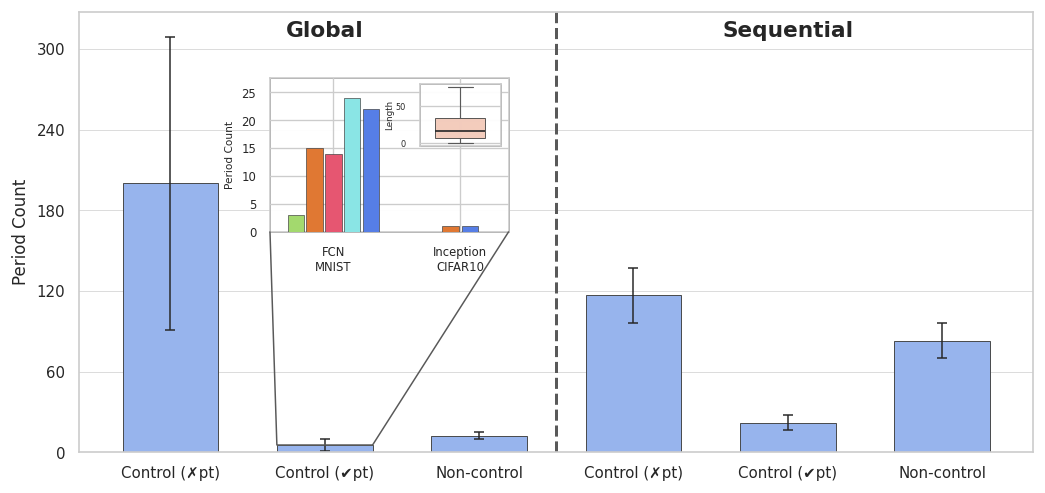

In [4]:
plot_report_summary_group_figure(
	df_period_runs,
	plot_dir=PLOT_DIR,
	filename="final_btsp_requires_novelty.pdf",
	title=None,#"BTSP requires novelty",
	ylabel="Period Count",
	sem_axis=REPORT_SUMMARY_SEM_AXIS,
	save=True,
	show=True,
	all_results=all_results,
	project_root=PROJECT_ROOT,
)

summary_period = aggregate_report_summary_sem(
	df_period_runs,
	sem_axis=REPORT_SUMMARY_SEM_AXIS,
)
display(summary_period)

/home/garvalov/thesis/plateau_optimizer/network_analyzer/.venv/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:592: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
/home/garvalov/thesis/plateau_optimizer/network_analyzer/.venv/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:592: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
/home/garvalov/thesis/plateau_optimizer/network_analyzer/.venv/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:592: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypote

Saved /home/garvalov/thesis/plateau_optimizer/network_analyzer/analysis/notebooks/local/save/plots/report/final/final_btsp_requires_novelty_non_control_global.pdf


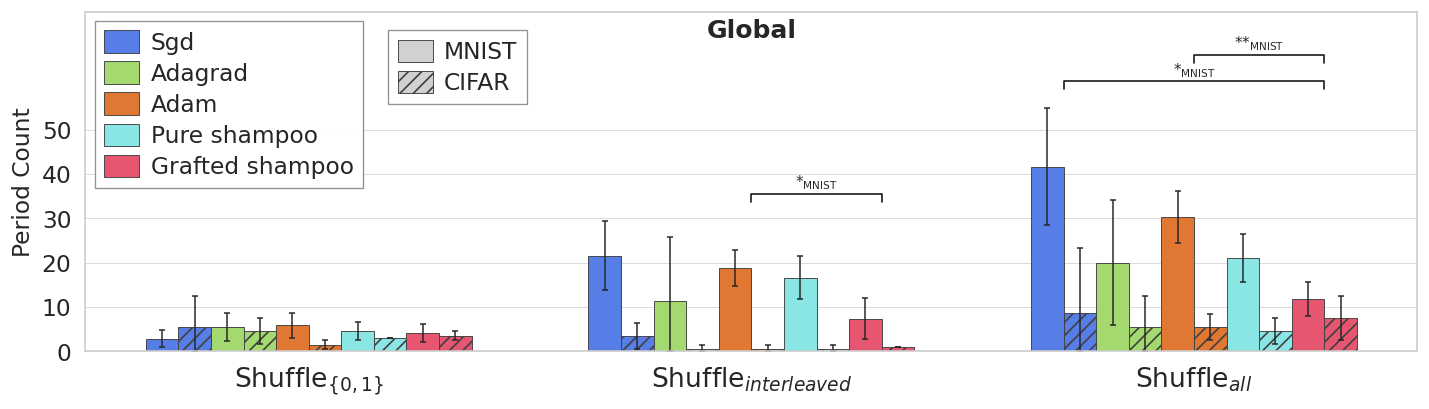

MNIST–CIFAR Spearman ρ (per optimizer; MNIST seeds vs pooled CIFAR) — Non-control global
Two-way ANOVA on ranks — Non-control global
  n = 135, residual df = 120
                   effect    sum_sq  df   mean_sq     F   p_value
               experiment 7.167e+04   2 3.584e+04 35.87 6.156e-13
             optimizer_id 2.456e+04   4      6140 6.145 0.0001562
experiment × optimizer_id 1.182e+04   8      1477 1.479     0.172


,optimizer_id,n_mnist_runs,spearman_rho,p_value
0,sgd,21,0.308506,0.173624
1,adagrad,21,0.521623,0.015300
2,adam,21,0.366590,0.102145
3,pure_shampoo,21,0.222464,0.332420
4,grafted_shampoo,21,0.339087,0.132657


Saved /home/garvalov/thesis/plateau_optimizer/network_analyzer/analysis/notebooks/local/save/plots/report/final/final_btsp_requires_novelty_non_control_sequential.pdf


/home/garvalov/thesis/plateau_optimizer/network_analyzer/.venv/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:592: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
/home/garvalov/thesis/plateau_optimizer/network_analyzer/.venv/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:592: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
/home/garvalov/thesis/plateau_optimizer/network_analyzer/.venv/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:592: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypote

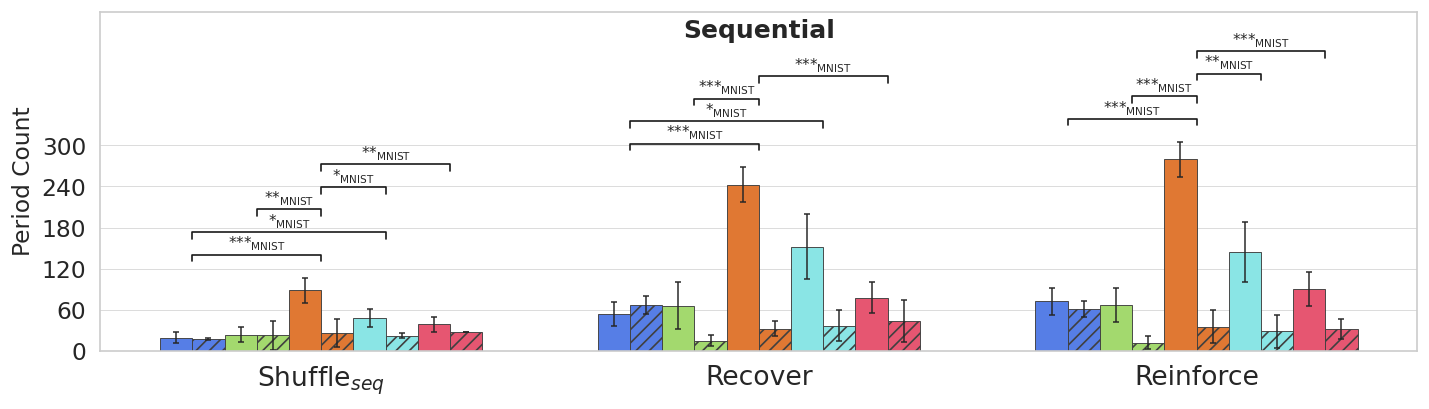

MNIST–CIFAR Spearman ρ (per optimizer; MNIST seeds vs pooled CIFAR) — Non-control sequential
Two-way ANOVA on ranks — Non-control sequential
  n = 135, residual df = 120
                   effect    sum_sq  df   mean_sq      F   p_value
               experiment 5.056e+04   2 2.528e+04  28.26 8.769e-11
             optimizer_id  5.04e+04   4  1.26e+04  14.09 1.879e-09
experiment × optimizer_id      3329   8     416.2 0.4652    0.8784


,optimizer_id,n_mnist_runs,spearman_rho,p_value
0,sgd,21,0.544352,0.010733
1,adagrad,21,-0.611993,0.003193
2,adam,21,0.848116,0.000001
3,pure_shampoo,21,0.732226,0.000161
4,grafted_shampoo,21,0.433978,0.049344


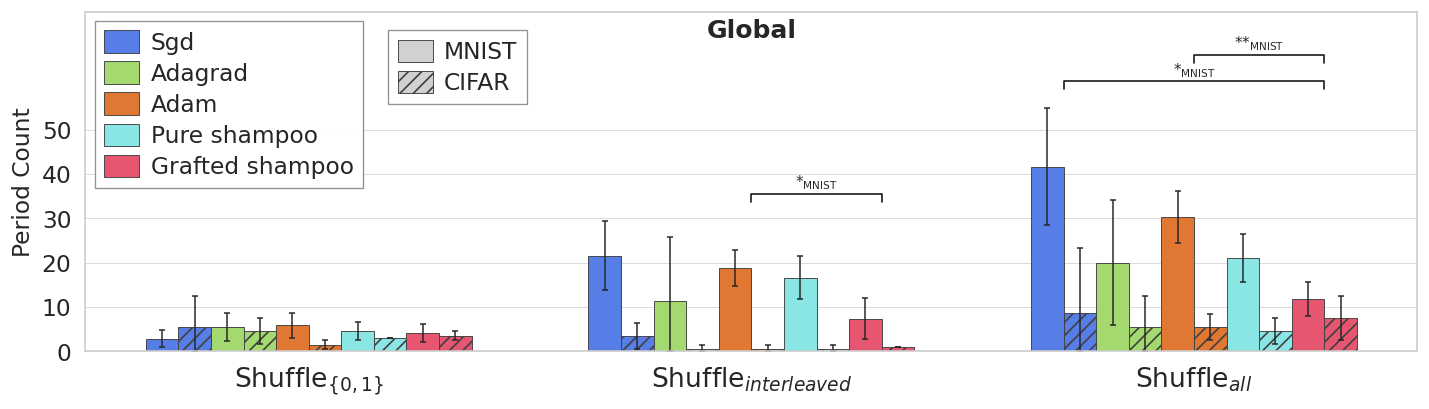

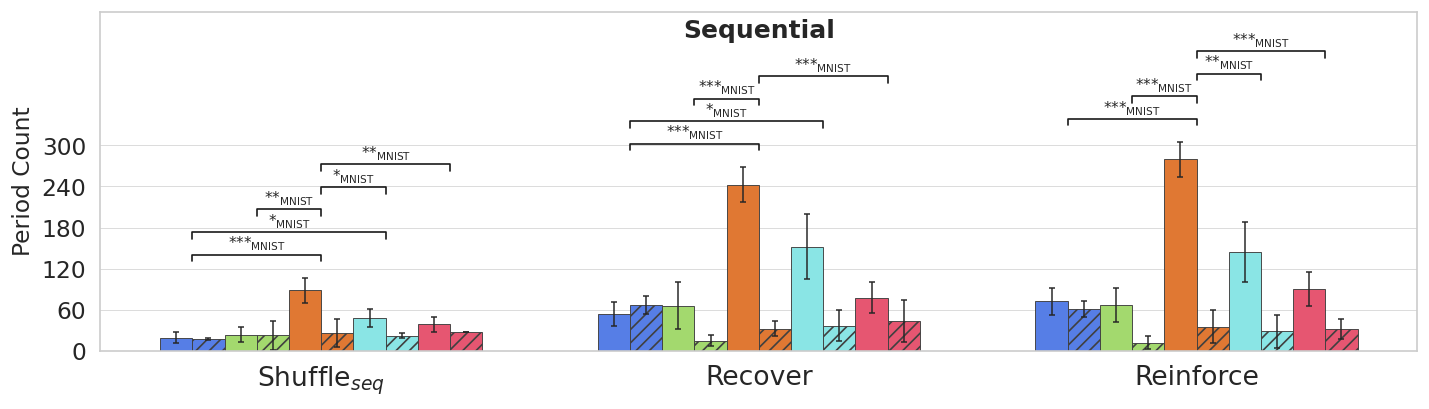

In [5]:
# Non-control experiments: MNIST + pooled CIFAR bar per optimizer (hatch = model)
for report_group, slug, panel_title in (
	("cat1_non_control", "global", "Non-control global"),
	("cat2_non_control", "sequential", "Non-control sequential"),
):
	sub = prepare_report_non_control_runs(
		df_period_runs,
		report_group=report_group,
		rename_experiment=rename_experiments,
	)
	agg = aggregate_experiment_optimizer_pooled_bar_sem(sub)


	_, spearman_df = plot_report_non_control_experiment_bars(
		df_period_runs,
		report_group=report_group,
		rename_experiment=rename_experiments,
		sort_experiment_names=_sort_experiment_display_names,
		plot_dir=PLOT_DIR,
		filename=f"final_btsp_requires_novelty_non_control_{slug}.pdf",
		ylabel="Period Count",
		save=True,
		show=True,
	)
	# display(
	# 	agg.sort_values(["experiment", "optimizer_id", "model_id"]).reset_index(drop=True)
	# )
	print(f"MNIST–CIFAR Spearman ρ (per optimizer; MNIST seeds vs pooled CIFAR) — {panel_title}")
	print_two_way_anova_on_ranks(sub, title=panel_title)
	display(spearman_df)

Saved /home/garvalov/thesis/plateau_optimizer/network_analyzer/analysis/notebooks/local/save/plots/report/final/final_t_start_non_control_neighbor_bar.pdf


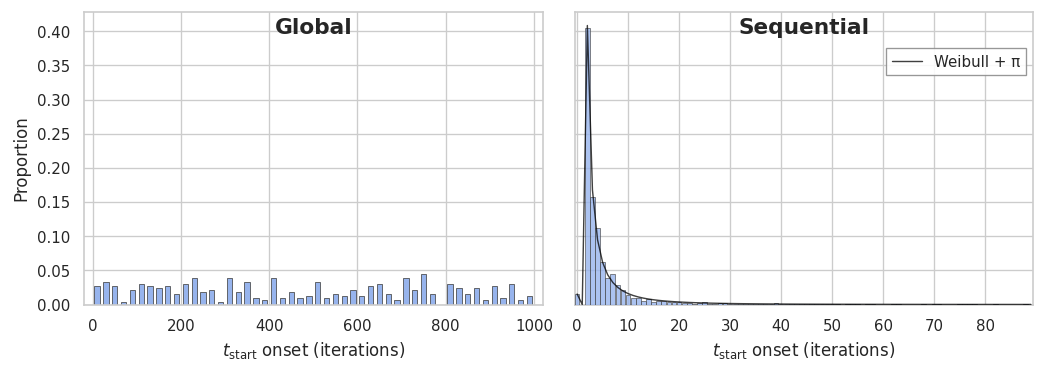

Best π-inflated fit to sequential bins: Weibull + π (bin RMSE=0.0027, params={'pi': 0.015318195321490695, 'lam': 0.22042755561597857, 'beta': 0.33207358349062865, 'k_first_tail': 2.0})


,model,label,bin_rmse,pi,p,k_first_tail,r,alpha,kappa,mu,sigma,lam,beta,s
6,weibull_zi,Weibull + π,0.002743,0.015318,NaN,2.0,NaN,NaN,NaN,NaN,NaN,0.220428,0.332074,NaN
4,lognormal_zi,lognormal + π,0.002799,0.015318,NaN,2.0,NaN,NaN,NaN,-0.25994,1.685138,NaN,NaN,NaN
3,power_law_cutoff_zi,power law + exp cutoff + π,0.003526,0.015320,NaN,2.0,NaN,1.348395,27.527916,NaN,NaN,NaN,NaN,NaN
1,negbinom_zi,neg. binomial + π,0.006330,0.015318,0.074290,2.0,0.000001,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,zipf_zi,Zipf + π,0.007565,0.015318,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.618431
2,power_law_zi,power law + π,0.007565,0.015318,NaN,2.0,NaN,1.618431,NaN,NaN,NaN,NaN,NaN,NaN
5,exponential_zi,exponential + π,0.022518,0.015318,NaN,2.0,NaN,NaN,NaN,NaN,NaN,0.234176,NaN,NaN
0,geometric_zi,geometric + π,0.022518,0.015318,0.208777,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


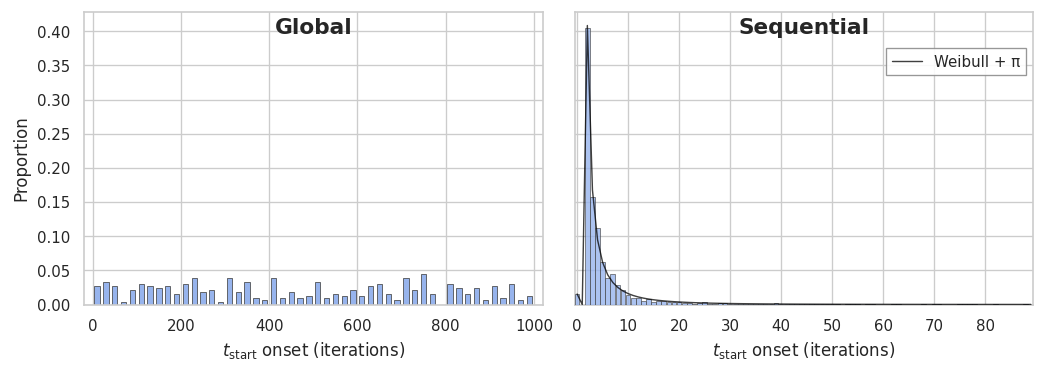

In [6]:
# Pooled t_start offset distributions (non-control global | sequential)
from analysis.final.report_plots.t_start_zi_fits import REPORT_ZI_MODEL_LABELS

_results_seed = filter_all_results_seed(all_results, seed=DEFAULT_SEED)
_period_offset_df = build_period_novelty_offset_df(_results_seed, rename_experiments)

_, _best_zi_fit, _all_zi_fits = plot_report_t_start_non_control_neighbor_bar_figure(
	_period_offset_df,
	plot_dir=PLOT_DIR,
	filename="final_t_start_non_control_neighbor_bar.pdf",
	show_zi_fit_overlay=True,
	save=True,
	show=True,
	return_zi_fit=True,
)
if _best_zi_fit is not None:
	print(
		f"Best π-inflated fit to sequential bins: "
		f"{REPORT_ZI_MODEL_LABELS[_best_zi_fit.model]} "
		f"(bin RMSE={_best_zi_fit.bin_rmse:.4f}, params={_best_zi_fit.params})"
	)
	display(
		pd.DataFrame(
			[
				{
					"model": key,
					"label": REPORT_ZI_MODEL_LABELS[key],
					"bin_rmse": fit.bin_rmse,
					**fit.params,
				}
				for key, fit in _all_zi_fits.items()
				
			]
		).sort_values("bin_rmse")
	)


## Optimizer profiles

Seed **3003** only. Spider profiles: row 1 = non-control Cat1 pooled; row 2 = Cat2 shuffle-seq / recover / reinforce pooled. Spoke labels: $\ell(b_j)$, TTC_first (Cat1) / TTC_each (Cat2). Then activation angle (flat mean ± 1.96·SEM over all non-control experiments × optimizers) and $t_{\mathrm{start}}$ offset eCDFs with CvM insets.

In [7]:
all_results_seed = filter_all_results_seed(all_results, seed=DEFAULT_SEED)
print(f"seed {DEFAULT_SEED} runs: {len(all_results_seed)} / {len(all_results)}")

df_long = build_df_long(all_results_seed, rename_experiments)
df_ttc = build_report_ttc_long(all_results_seed, rename_experiments)
df_theta = build_report_theta_long(all_results_seed, rename_experiments)
spider_means = build_report_spider_means(df_long, df_ttc)
print(f"spider_means rows={len(spider_means)}")

seed 3003 runs: 150 / 150
spider_means rows=675


Cat1 non-control pool: ['$\\text{Shuffle}_{\\{0,1\\}}$', '$\\text{Shuffle}_{interleaved}$', '$\\text{Shuffle}_{all}$']
Saved /home/garvalov/thesis/plateau_optimizer/network_analyzer/analysis/notebooks/local/save/plots/report/final/final_optimizer_profiles_spider.pdf


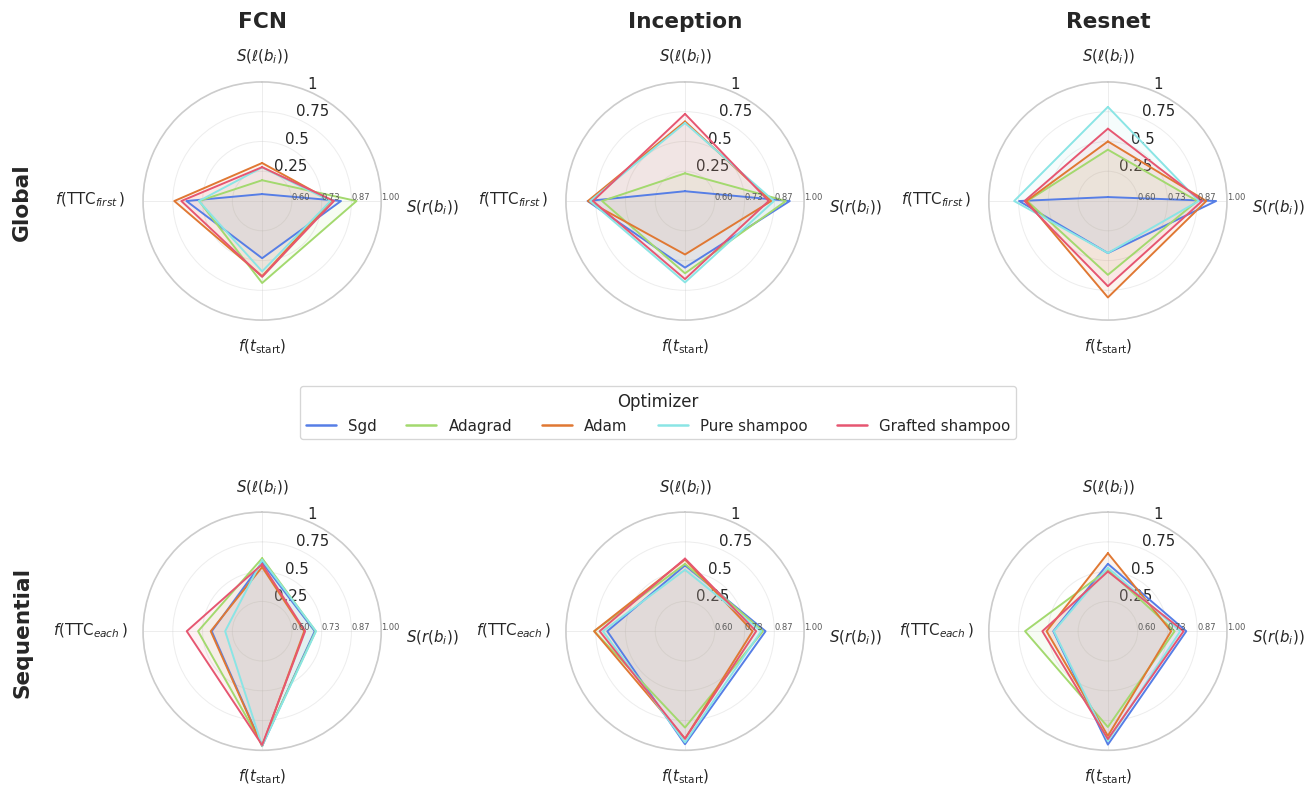

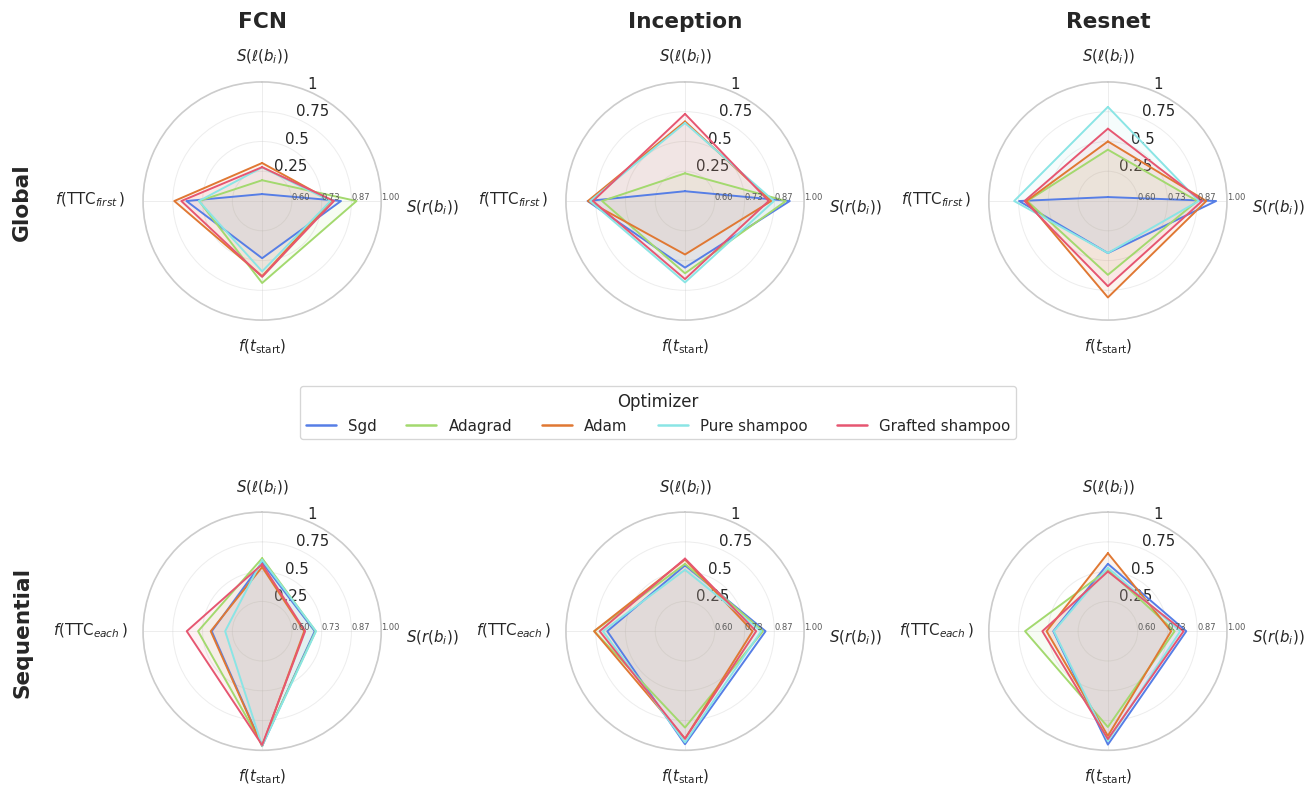

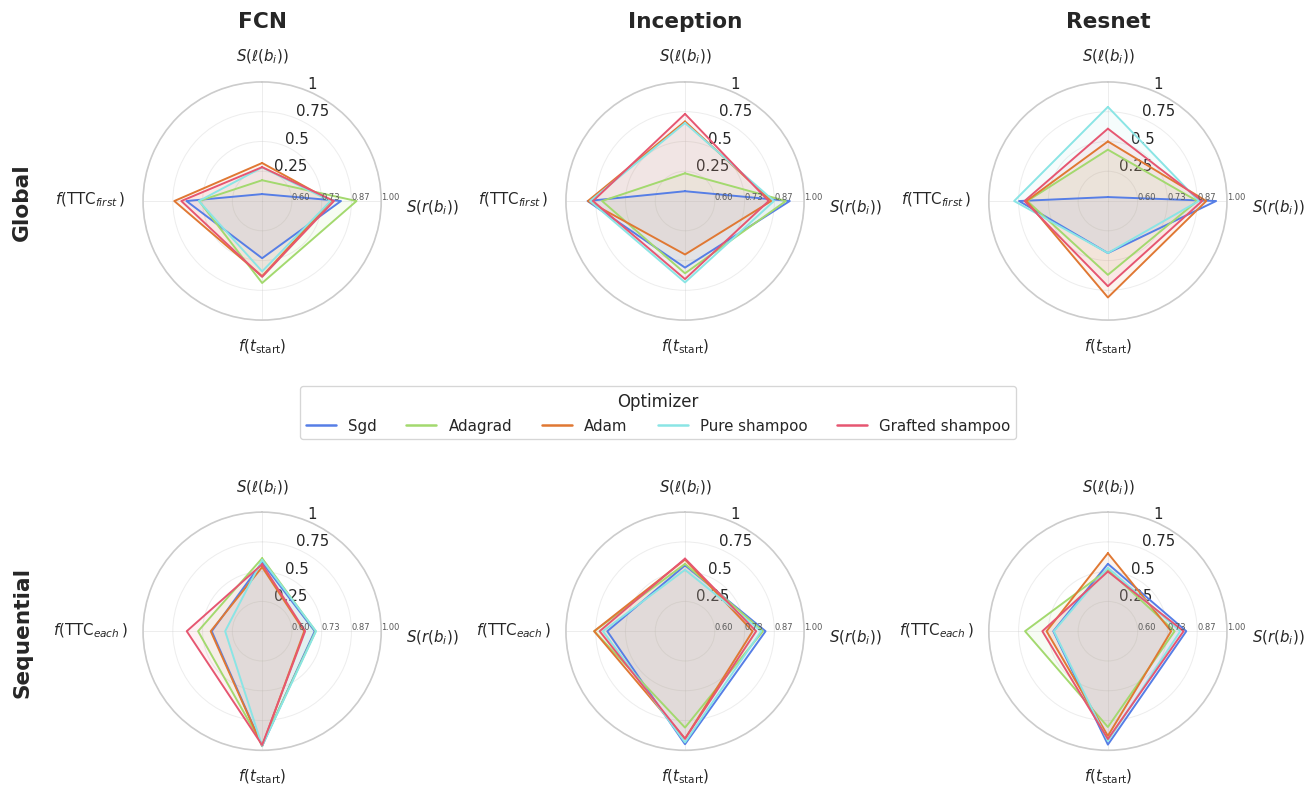

In [8]:
_SPIDER_LABEL_OVERRIDES = {
	"length": r"$S(\ell(b_i))$",
	"start_onset": r"$f(t_{\mathrm{start}})$",
	"robustness": r"$S(r(b_i))$",
}

cat1_pool = cat1_non_control_experiment_labels(
	spider_means["experiment"].unique(), LABELS
)
print(f"Cat1 non-control pool: {cat1_pool}")

plot_report_spider_pooled_figure(
	spider_means,
	labels=LABELS,
	plot_dir=PLOT_DIR,
	filename="final_optimizer_profiles_spider.pdf",
	title=None,
	show_angle=False,
	show=True,
	pool_rows=[
		(
			cat1_pool,
			{**_SPIDER_LABEL_OVERRIDES, "ttc": r"$f(\operatorname{TTC}_{first})$"},
		),
		(
			None,
			{**_SPIDER_LABEL_OVERRIDES, "ttc": r"$f(\operatorname{TTC}_{each})$"},
		),
	],
	row_labels=("Global", "Sequential"),
)

Saved /home/garvalov/thesis/plateau_optimizer/network_analyzer/analysis/notebooks/local/save/plots/report/final/final_activation_angle_by_model.pdf


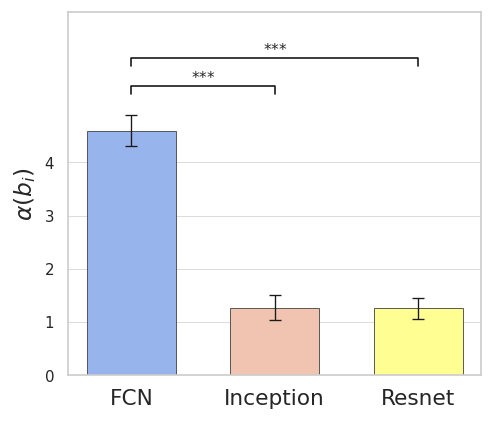

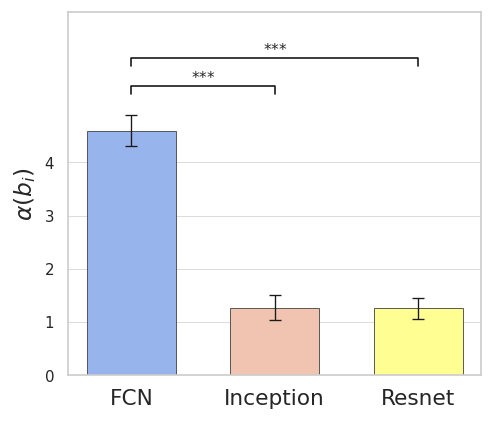

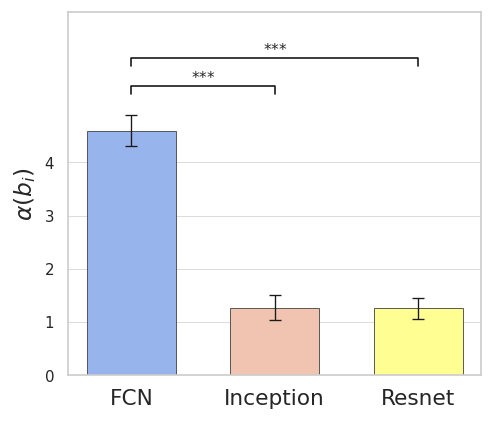

In [9]:
plot_report_activation_angle_by_model_figure(
	df_long,
	plot_dir=PLOT_DIR,
	filename="final_activation_angle_by_model.pdf",
	ylabel=r"$\alpha(b_i)$",
	show_significance=SHOW_SIGNIFICANCE,
	show_insignificance=False,
	show=True,
)

[Activation angle by optimizer (MNIST seq)] 8 significant pair(s) (Holm corrected):
  Sgd vs Adagrad: raw p=1.20e-03, Holm p=4.82e-03 (**)
  Sgd vs Pure shampoo: raw p=3.21e-04, Holm p=1.93e-03 (**)
  Sgd vs Grafted shampoo: raw p=5.00e-05, Holm p=3.50e-04 (***)
  Adagrad vs Adam: raw p=2.34e-06, Holm p=1.87e-05 (***)
  Adagrad vs Grafted shampoo: raw p=1.24e-02, Holm p=3.71e-02 (*)
  Adam vs Pure shampoo: raw p=2.14e-25, Holm p=1.93e-24 (***)
  Adam vs Grafted shampoo: raw p=2.99e-30, Holm p=2.99e-29 (***)
  Pure shampoo vs Grafted shampoo: raw p=6.07e-04, Holm p=3.04e-03 (**)
Saved /home/garvalov/thesis/plateau_optimizer/network_analyzer/analysis/notebooks/local/save/plots/report/final/final_activation_angle_by_optimizer_mnist_seq.pdf


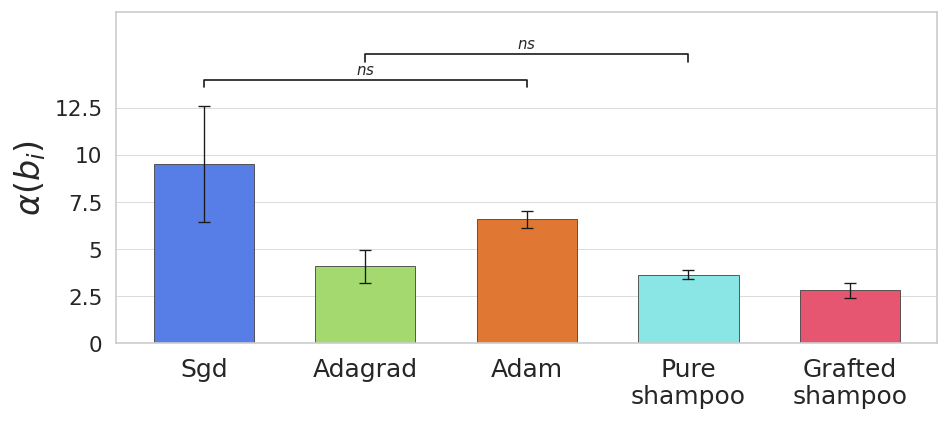

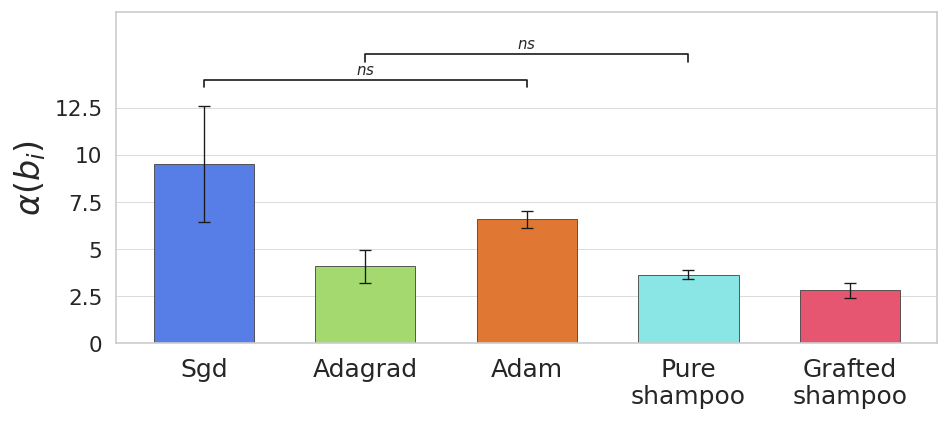

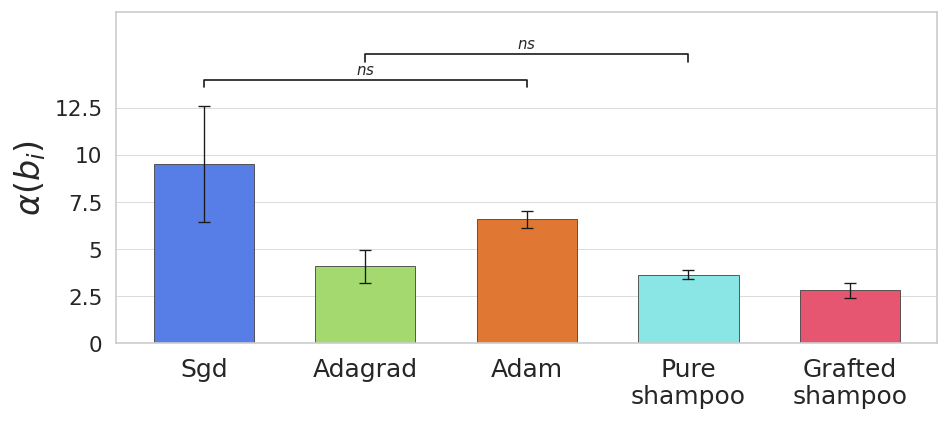

In [10]:
plot_report_activation_angle_by_optimizer_figure(
	df_long,
	plot_dir=PLOT_DIR,
	filename="final_activation_angle_by_optimizer_mnist_seq.pdf",
	ylabel=r"$\alpha(b_i)$",
	show_significance=SHOW_SIGNIFICANCE,
	show_insignificance=SHOW_INSIGNIFICANCE,
	show=True,
)

FCN non-control periods with angle > 45° and length > 100 (proportion of all periods):
  Sgd         : n=   7 /  190 (  3.7%)
  Adagrad     : n=   0 /  153 (  0.0%)
  Adam        : n=   0 /  581 (  0.0%)
  Pure shampoo: n=   0 /  553 (  0.0%)
  Grafted shampoo: n=   0 /  339 (  0.0%)
FCN non-control periods with angle > 45° only (proportion of all periods):
  Sgd         : n=   8 /  190 (  4.2%)
  Adagrad     : n=   0 /  153 (  0.0%)
  Adam        : n=   0 /  581 (  0.0%)
  Pure shampoo: n=   0 /  553 (  0.0%)
  Grafted shampoo: n=   0 /  339 (  0.0%)
FCN non-control periods with angle > 75° only (proportion of all periods):
  Sgd         : n=   1 /  190 (  0.5%)
  Adagrad     : n=   0 /  153 (  0.0%)
  Adam        : n=   0 /  581 (  0.0%)
  Pure shampoo: n=   0 /  553 (  0.0%)
  Grafted shampoo: n=   0 /  339 (  0.0%)
Saved /home/garvalov/thesis/plateau_optimizer/network_analyzer/analysis/notebooks/local/save/plots/report/final/final_steep_long_period_count_by_optimizer_fcn_non_contro

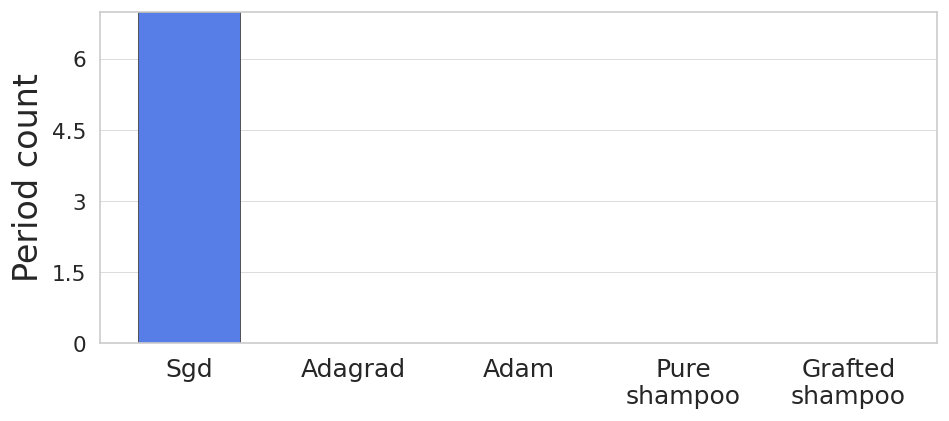

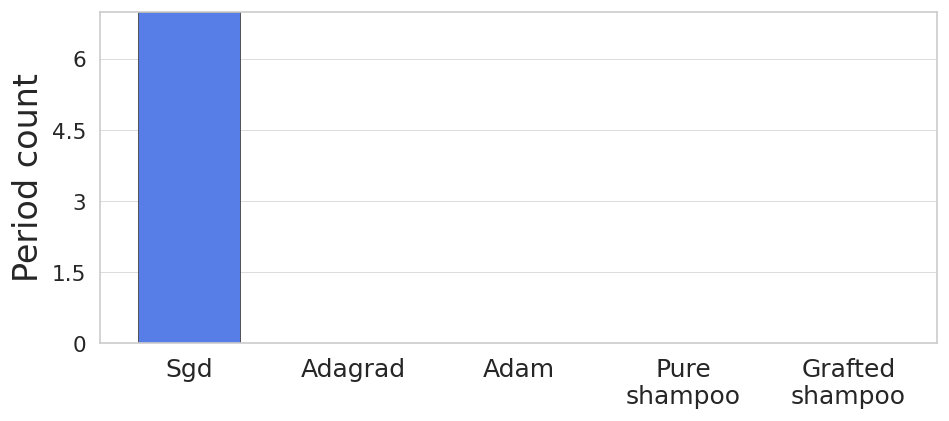

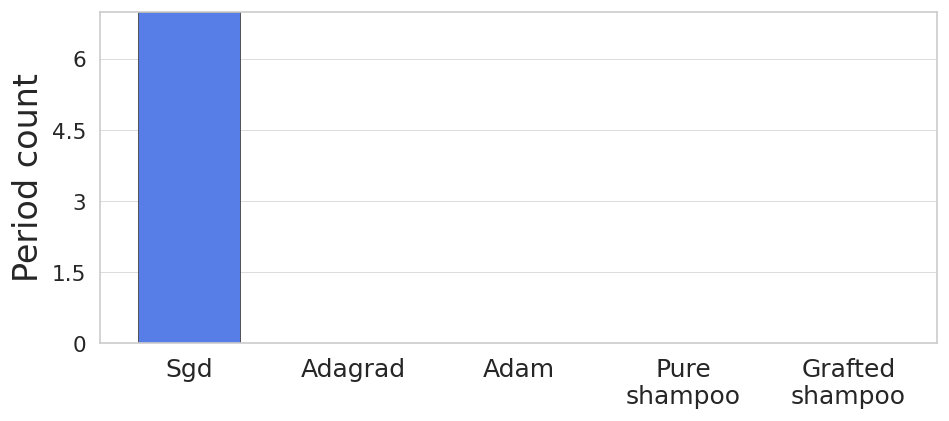

In [11]:
plot_report_steep_long_period_count_by_optimizer_figure(
	all_results_seed,
	plot_dir=PLOT_DIR,
	filename="final_steep_long_period_count_by_optimizer_fcn_non_control.pdf",
	ylabel="Period count",
	show_significance=SHOW_SIGNIFICANCE,
	show_insignificance=SHOW_INSIGNIFICANCE,
	show=True,
)

Saved /home/garvalov/thesis/plateau_optimizer/network_analyzer/analysis/notebooks/local/save/plots/report/final/final_theta_threshold_by_optimizer.pdf


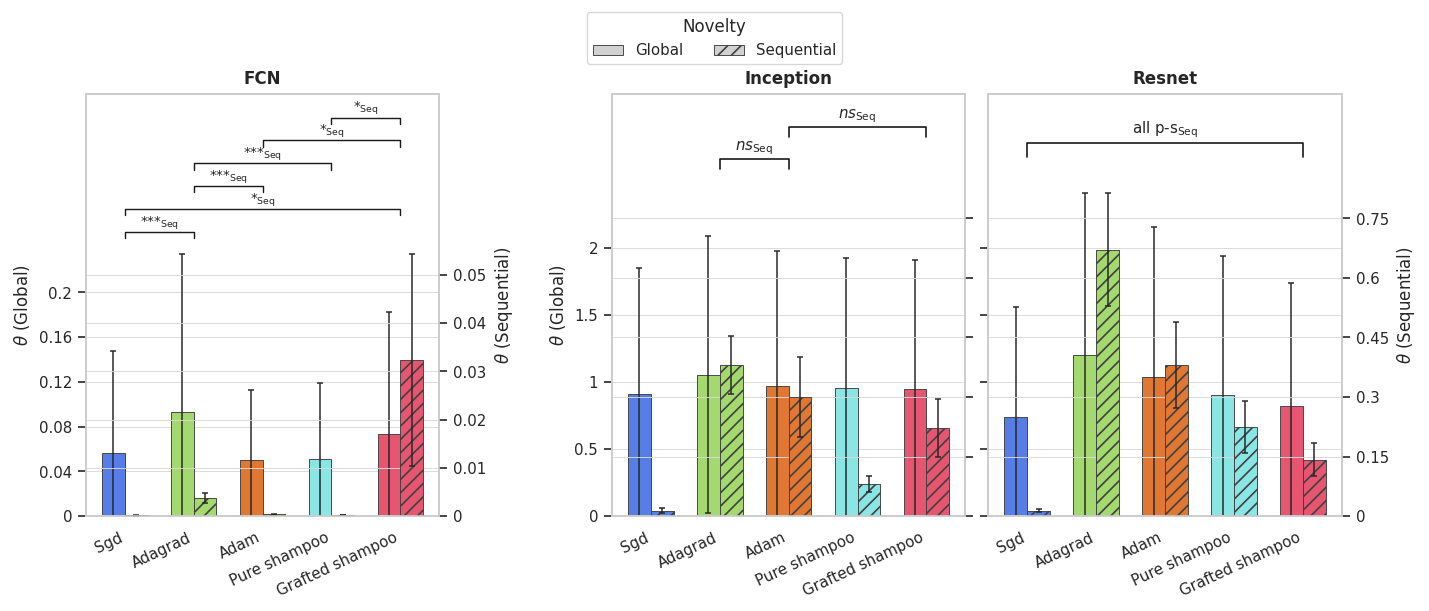

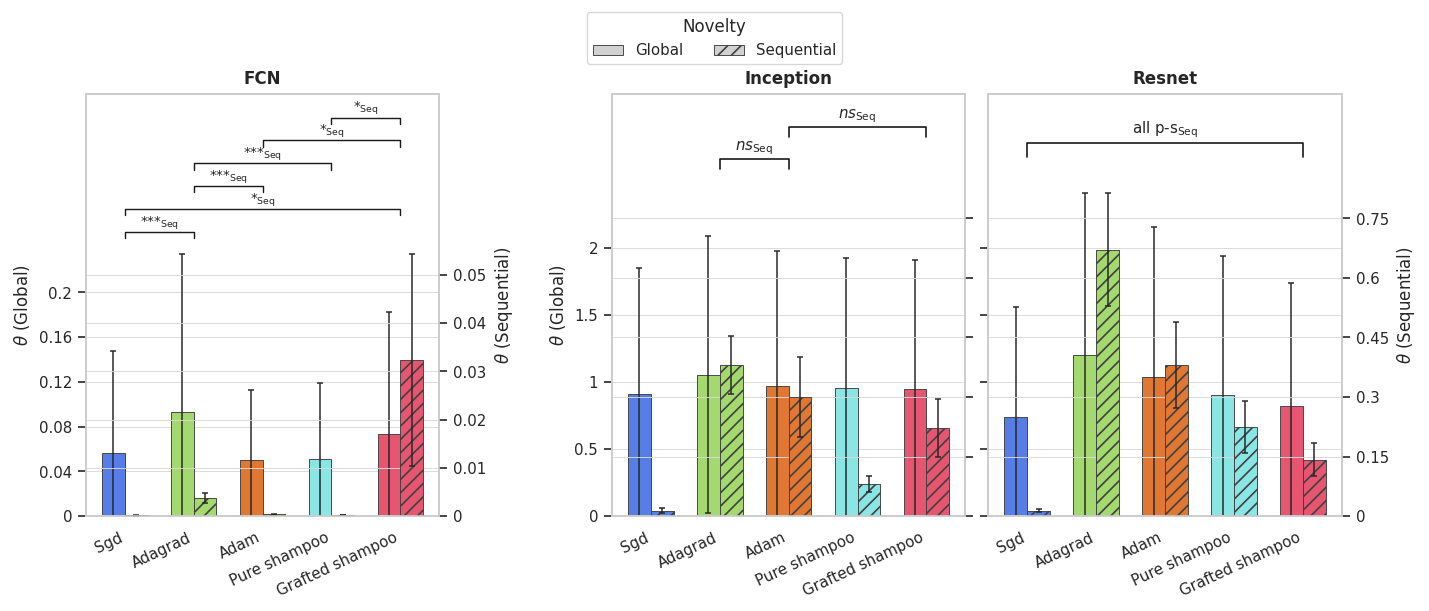

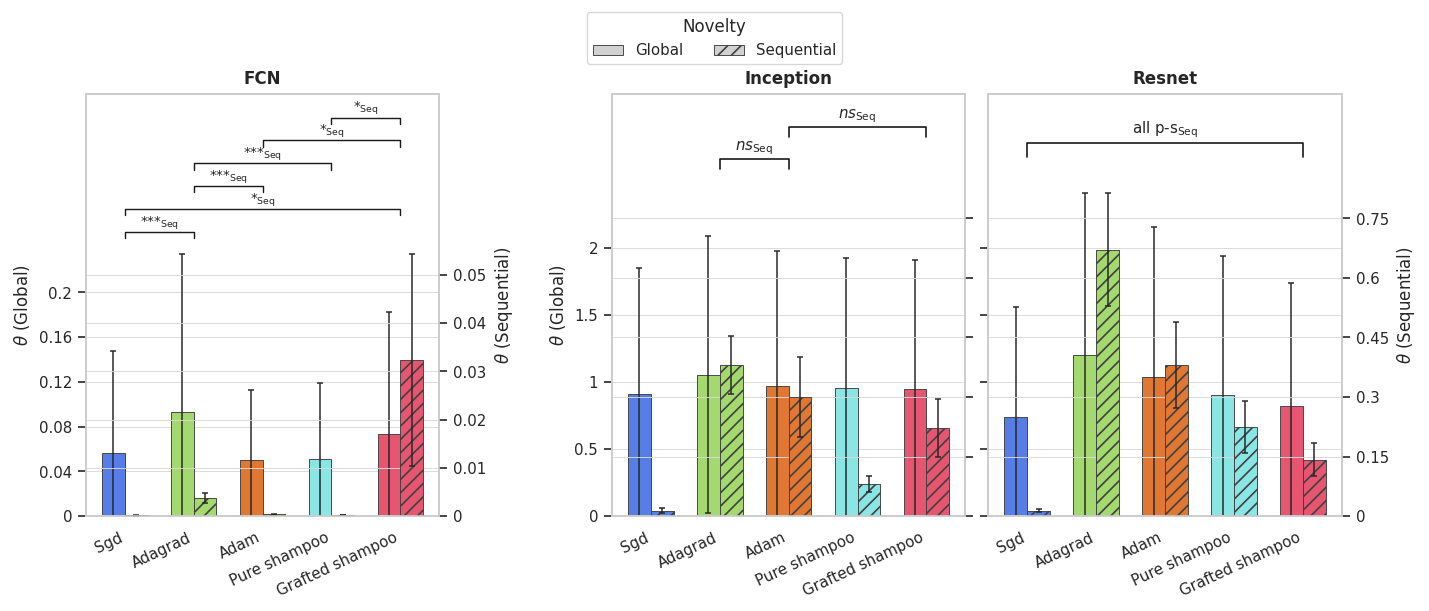

In [12]:
plot_report_theta_threshold_by_optimizer_figure(
	df_theta,
	plot_dir=PLOT_DIR,
	filename="final_theta_threshold_by_optimizer.pdf",
	ylabel=r"$\theta$",
	show_significance=SHOW_SIGNIFICANCE,
	show_insignificance=SHOW_INSIGNIFICANCE,
	show=True,
)

period_offset_df rows=11606


/home/garvalov/thesis/plateau_optimizer/network_analyzer/analysis/final/report_plots/style.py:80: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Saved /home/garvalov/thesis/plateau_optimizer/network_analyzer/analysis/notebooks/local/save/plots/report/final/final_t_start_comparison.pdf


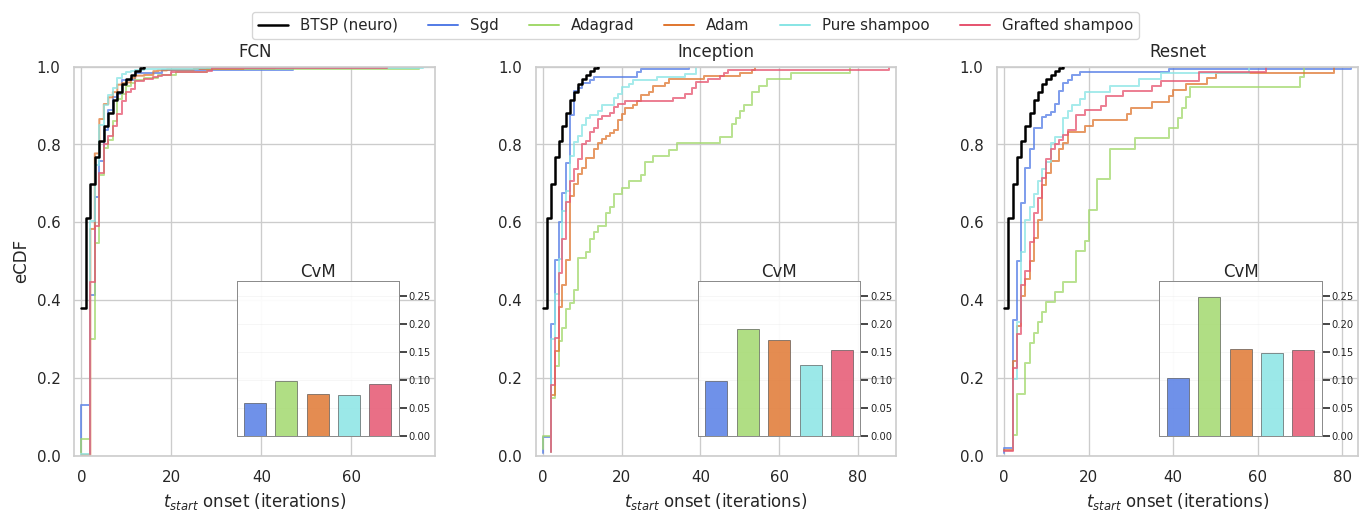

,model_id,optimizer_id,n,auc,cvm,cvm_p
0,dnn_5x64,sgd,116,0.933510,0.059758,0.0001
1,dnn_5x64,adagrad,143,0.920864,0.097892,0.0001
2,dnn_5x64,adam,520,0.937711,0.075252,0.0001
3,dnn_5x64,pure_shampoo,512,0.938599,0.073482,0.0001
4,dnn_5x64,grafted_shampoo,296,0.923647,0.092132,0.0001
5,inception_small_dnn_5x64,sgd,145,0.928397,0.098560,0.0001
6,inception_small_dnn_5x64,adagrad,61,0.774956,0.190489,0.0001
7,inception_small_dnn_5x64,adam,123,0.875590,0.170897,0.0001
8,inception_small_dnn_5x64,pure_shampoo,113,0.906894,0.127301,0.0001
9,inception_small_dnn_5x64,grafted_shampoo,126,0.880089,0.153672,0.0001


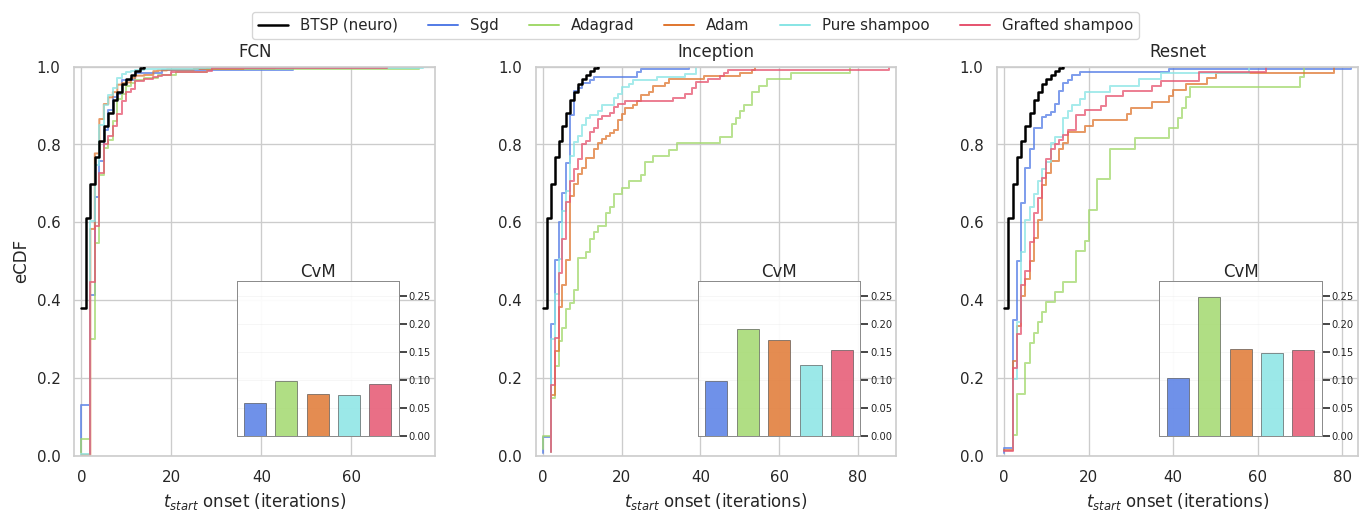

In [13]:
NEURO_EXPERIMENTAL_PATH = PROJECT_ROOT / "analysis/notebooks/parsed_bars.csv"
assert NEURO_EXPERIMENTAL_PATH.is_file(), (
	f"neuro ground-truth file missing: {NEURO_EXPERIMENTAL_PATH.resolve()}"
)
neuro_experimental_bars = load_neuro_experimental_bars(NEURO_EXPERIMENTAL_PATH)

period_offset_df = build_period_novelty_offset_df(all_results_seed, rename_experiments)
print(f"period_offset_df rows={len(period_offset_df)}")

_, t_start_metrics = plot_report_t_start_comparison_figure(
	period_offset_df,
	neuro_experimental_bars,
	labels=LABELS,
	plot_dir=PLOT_DIR,
	filename="final_t_start_comparison.pdf",
	title=None,
	include_other_neuro=False,
	show_auc=False,
	metric_layout="cvm_inset",
	show=True,
)
display(t_start_metrics)

## Layerwise analysis

Seed **3003** only. Cat2 non-control pooled (shuffle-seq / recover / reinforce): BTSP neuron % and period % by layer (top / bottom row), then layer-wise BSS violins with pooled mean fit.

Aggregation is split from plotting so you can re-run the plot cell while iterating on styling.

In [14]:
all_results_seed = filter_all_results_seed(all_results, seed=DEFAULT_SEED)

layerwise_btsp_data = build_report_layerwise_btsp_pct_data(
	all_results_seed,
	rename_experiments,
	labels=LABELS,
)
layerwise_bss_data = build_report_layerwise_bss_data(
	all_results_seed,
	rename_experiments,
	labels=LABELS,
)
print(
	f"layerwise BTSP rows: neuron={len(layerwise_btsp_data.neuron_all)} "
	f"period={len(layerwise_btsp_data.period_all)}"
)
print(
	f"layerwise BSS rows: mean={len(layerwise_bss_data.bss_all)} "
	f"samples={len(layerwise_bss_data.bss_samples)}"
)

/home/garvalov/thesis/plateau_optimizer/network_analyzer/analysis/io.py:57: DtypeWarning: Columns (0: layer_name) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(str(path))


layerwise BTSP rows: neuron=75 period=75
layerwise BSS rows: mean=64 samples=2546


Saved /home/garvalov/thesis/plateau_optimizer/network_analyzer/analysis/notebooks/local/save/plots/report/final/final_layerwise_btsp_pct.pdf


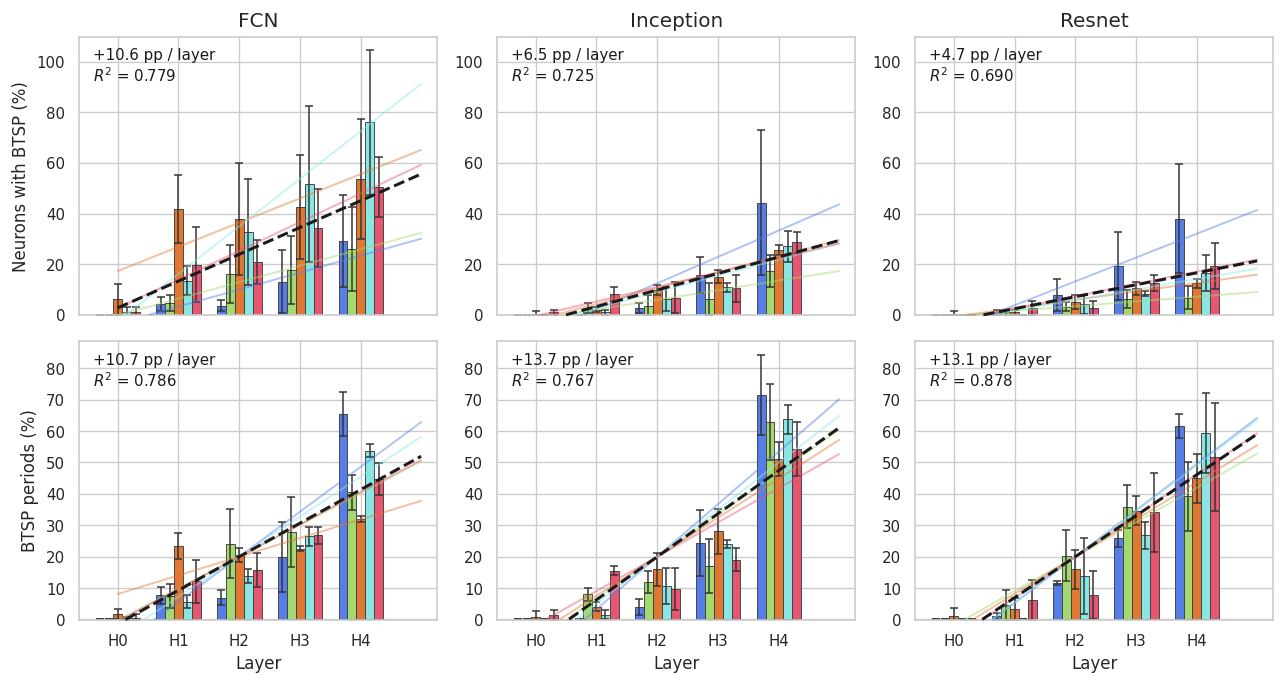

Saved /home/garvalov/thesis/plateau_optimizer/network_analyzer/analysis/notebooks/local/save/plots/report/final/final_pooled_bss_by_optimizer.pdf


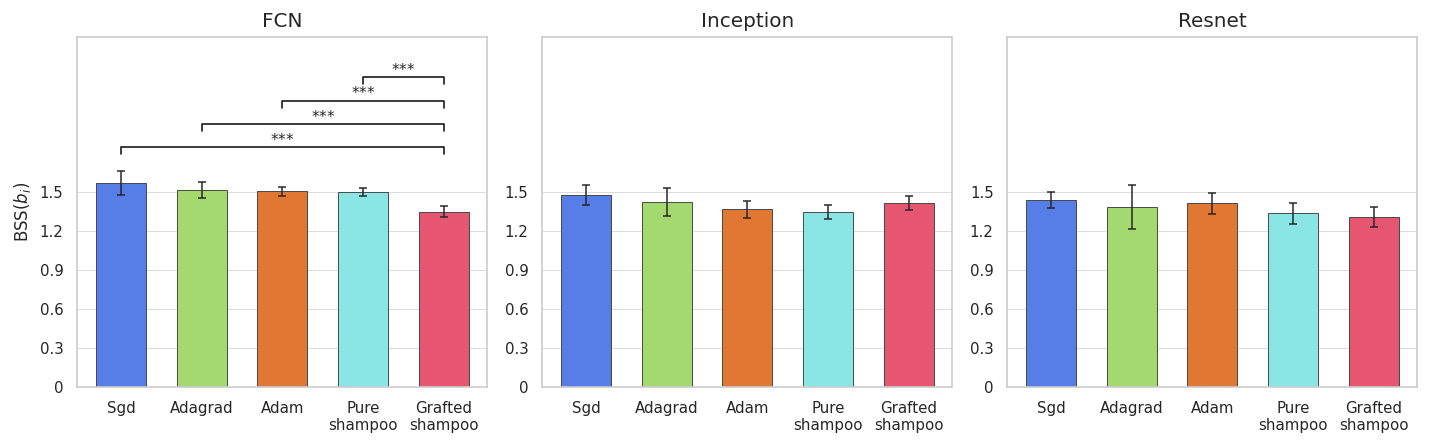

Saved /home/garvalov/thesis/plateau_optimizer/network_analyzer/analysis/notebooks/local/save/plots/report/final/final_layerwise_bss.pdf


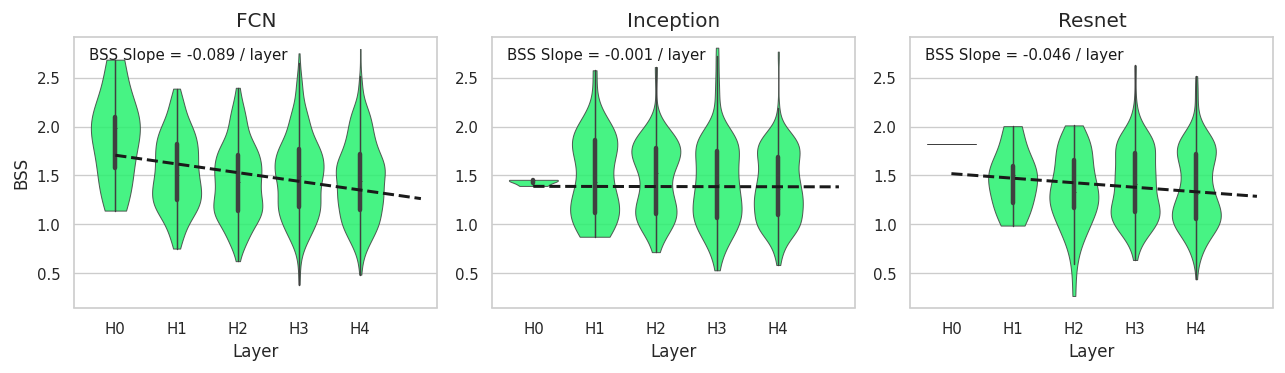

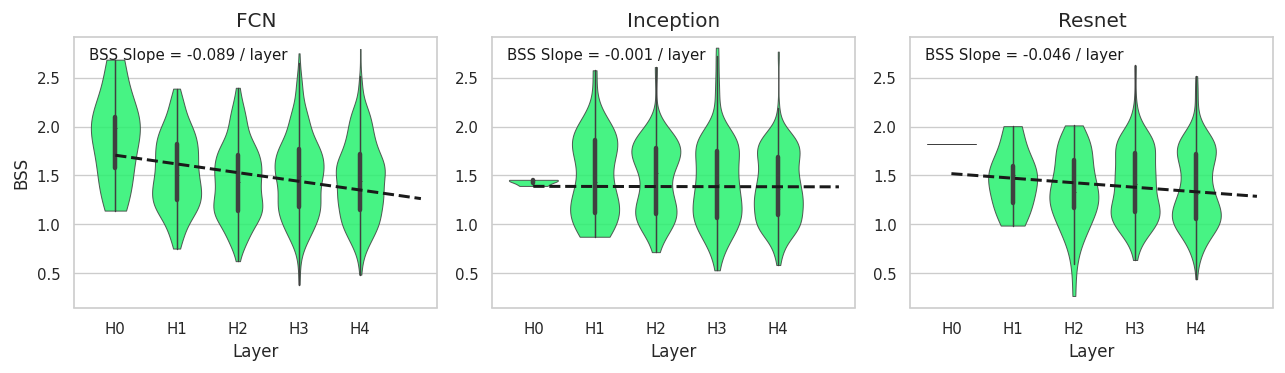

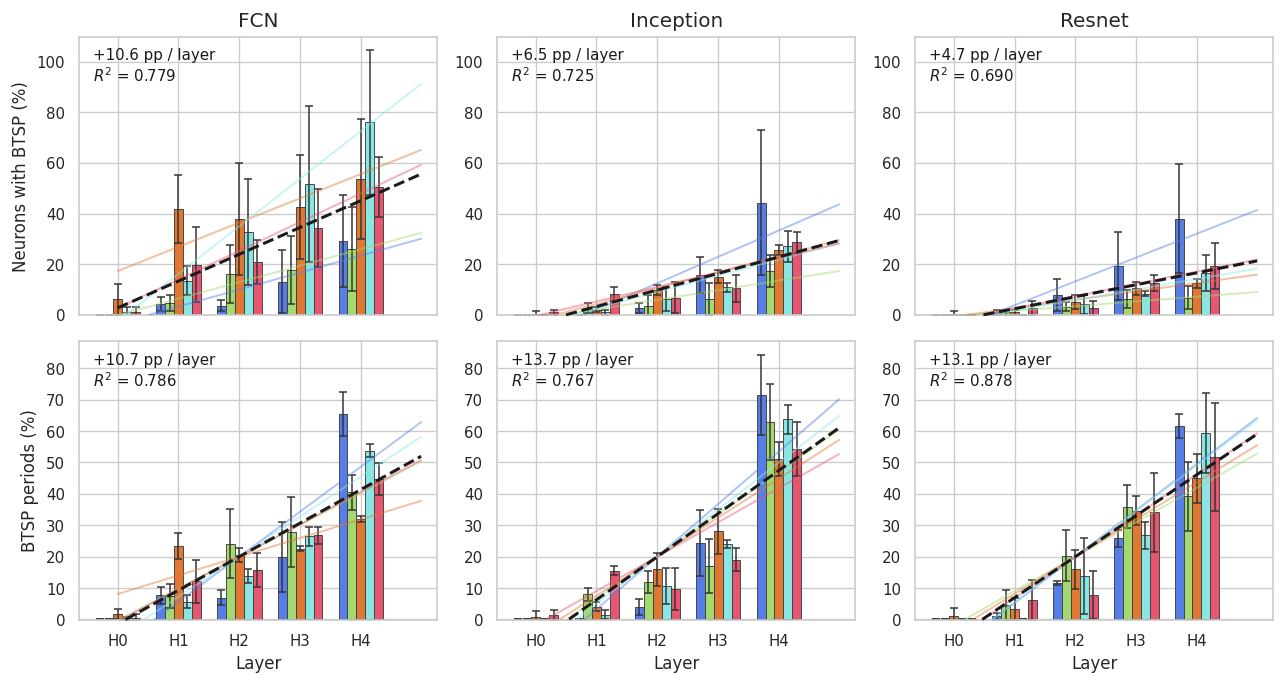

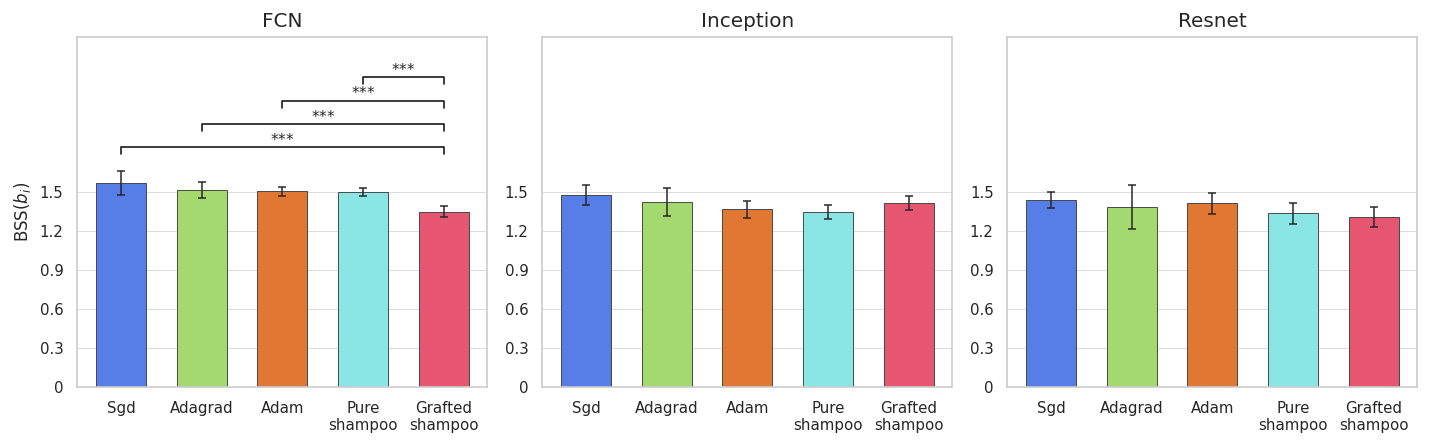

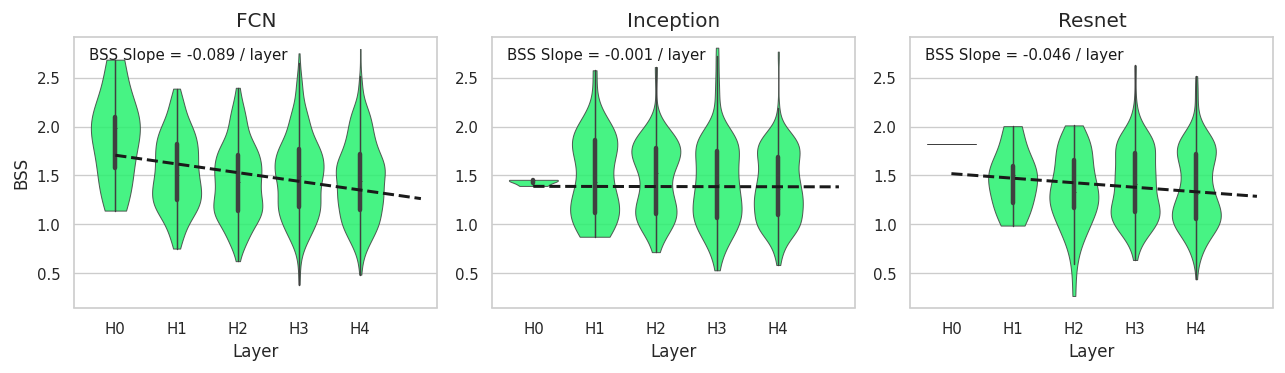

In [15]:
plot_report_layerwise_btsp_pct_from_data(
	layerwise_btsp_data,
	labels=LABELS,
	plot_dir=PLOT_DIR,
	filename="final_layerwise_btsp_pct.pdf",
	final_style=True,
	show=True,
)

plot_report_pooled_bss_by_optimizer_from_data(
	layerwise_bss_data,
	labels=LABELS,
	plot_dir=PLOT_DIR,
	filename="final_pooled_bss_by_optimizer.pdf",
	show=True,
	show_significance=SHOW_SIGNIFICANCE,
	show_insignificance=SHOW_INSIGNIFICANCE,
)

plot_report_layerwise_bss_from_data(
	layerwise_bss_data,
	labels=LABELS,
	plot_dir=PLOT_DIR,
	filename="final_layerwise_bss.pdf",
	final_style=True,
	show=True,
)